In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# magic autoreload
%load_ext autoreload
%autoreload 2
from svd_imputer import Imputer
from sklearn.preprocessing import StandardScaler

In [2]:
fname = os.path.join("data","serie_17092025225957.csv")
df = pd.read_csv(fname,index_col=0)
df.index.name = "date"
df.drop(columns=[i for i in df.columns if "Unnamed:" in i],inplace=True)
# drop if column ha sless than x values
df = df.drop(columns='593/5')
df = df.loc[df['594/400']>0]
df = df.loc[df['602/187']<5]
df = df.dropna(thresh=30,axis=1)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 03/06/2002 00:00 to 11/09/2025 00:00
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   594/400  214 non-null    float64
 1   602/178  181 non-null    float64
 2   602/187  214 non-null    float64
 3   602/242  188 non-null    float64
 4   602/311  188 non-null    float64
 5   602/36   30 non-null     float64
 6   602/43   163 non-null    float64
 7   602/552  88 non-null     float64
 8   602/553  87 non-null     float64
 9   602/76   197 non-null    float64
dtypes: float64(10)
memory usage: 18.4+ KB


In [3]:
df.index = pd.to_datetime(df.index, format="%d/%m/%Y %H:%M")
df

,594/400,602/178,602/187,602/242,602/311,602/36,602/43,602/552,602/553,602/76
date,,,,,,,,,,
2002-06-03,3.32,3.31,3.52,5.93,4.96,NaN,4.28,NaN,NaN,4.58
2002-07-02,3.21,5.23,3.35,4.96,5.21,NaN,4.20,NaN,NaN,3.97
2002-11-05,2.91,5.01,3.23,4.90,4.94,NaN,3.98,NaN,NaN,4.28
2002-12-02,2.53,4.71,3.13,4.06,4.26,NaN,4.03,NaN,NaN,4.08
2003-01-06,3.41,5.37,3.69,5.30,5.41,NaN,4.36,NaN,NaN,5.04
...,...,...,...,...,...,...,...,...,...,...
2024-06-04,1.97,2.81,2.60,2.74,2.56,3.04,1.94,2.66,2.74,NaN
2024-10-09,1.43,2.11,2.13,1.76,NaN,NaN,NaN,1.83,2.40,1.39
2025-01-23,1.34,2.31,2.26,2.23,NaN,2.53,NaN,2.36,2.13,1.95


In [4]:
# get moving average
#df = df.rolling(window=3, min_periods=3).mean()

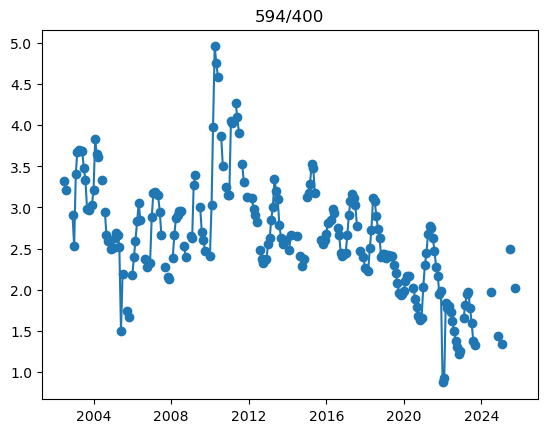

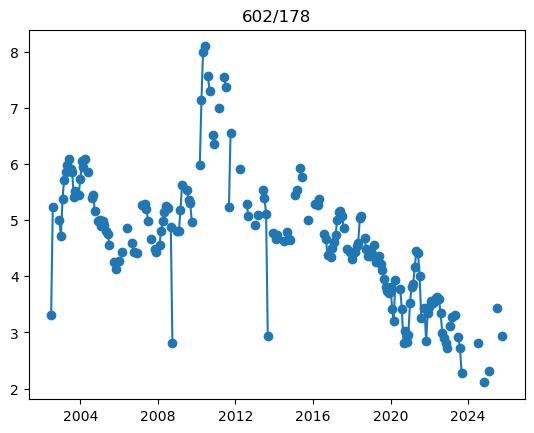

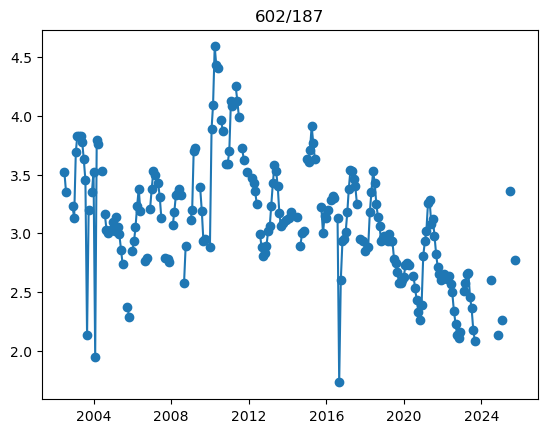

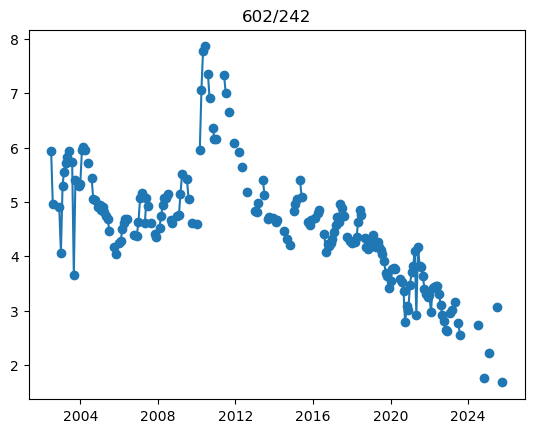

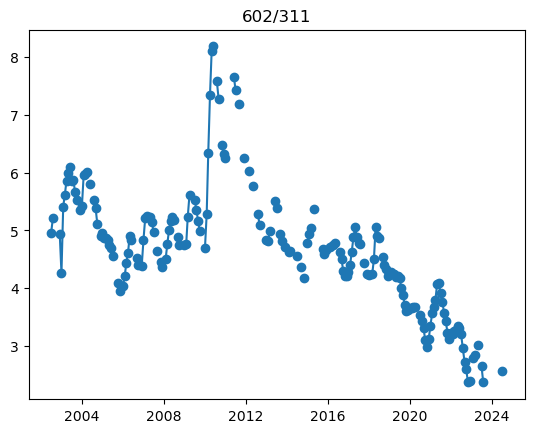

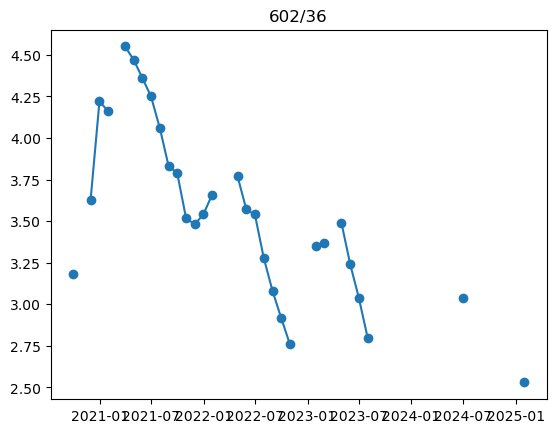

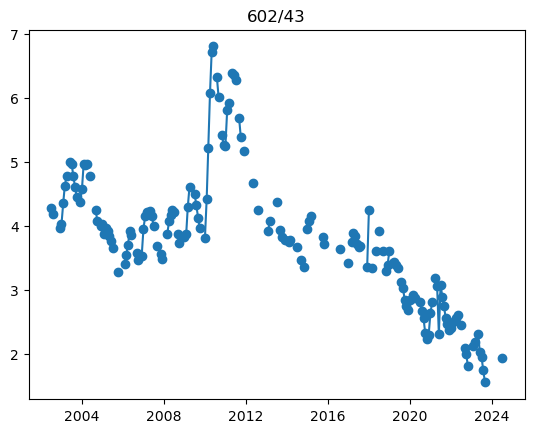

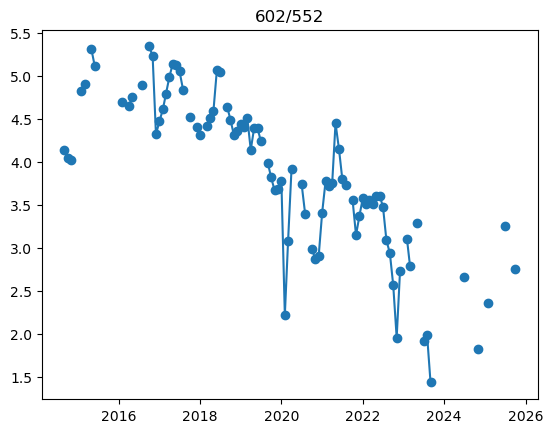

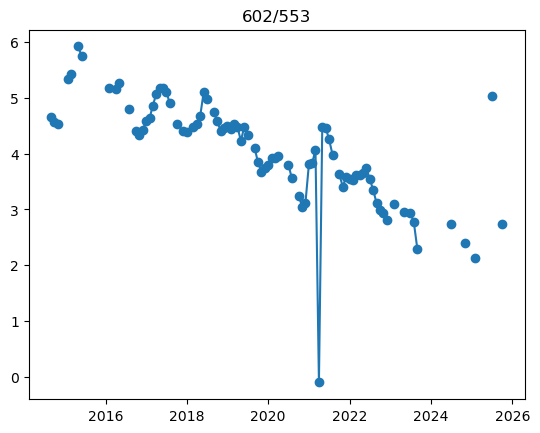

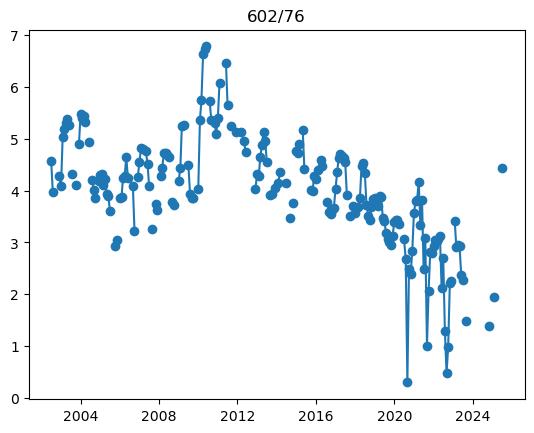

In [5]:
df = df.resample('ME').mean()
for col in df.columns:
    fig,ax = plt.subplots()
    ax.plot(df.index,df[col],'o-')
    ax.set_title(col)
    plt.show()

In [6]:
df.shape

(280, 10)

In [7]:
df = df.dropna(how='all',axis=0)

In [12]:
# Example 3: Hybrid Uncertainty (Best of both)
imputer_hybrid = Imputer(scaler=StandardScaler(),max_iters=10000)

df_imputed_hybrid, unc_hybrid = imputer_hybrid.fit_transform(
    df,
    return_uncertainty=True,
    uncertainty_method='hybrid',
    n_repeats=50,      # For Monte Carlo validation
    n_bootstrap=30,    # For bootstrap
    mask_strategy='block',
    block_len=6,
    confidence=0.95,
    seed=42
)

df_lower_hybrid, df_upper_hybrid = imputer_hybrid.get_confidence_intervals(df_imputed_hybrid, unc_hybrid)

print(f"Method: {unc_hybrid['method']}")
print(f"Monte Carlo RMSE: {unc_hybrid['monte_carlo']['rmse']:.4f}")
print(f"Bootstrap average CI width: {(df_upper_hybrid - df_lower_hybrid).mean().mean():.4f}")

Estimated rank: 1 (variance threshold: 95%)
Imputing with rank=1, max_iters=10000, tol=0.0001
Imputed 574 missing value(s)
Computing hybrid uncertainty...
Estimating uncertainty with 50 Monte Carlo repeats...
Strategy: block, Rank: 1
RMSE: 0.8905 (95% CI: 0.7268 - 1.0543)
MAE:  0.7764 (95% CI: 0.6205 - 0.9323)
Computing bootstrap uncertainty with 30 samples...
Average uncertainty (std): 1.7254
Method: hybrid
Monte Carlo RMSE: 0.8905
Bootstrap average CI width: 2.2490


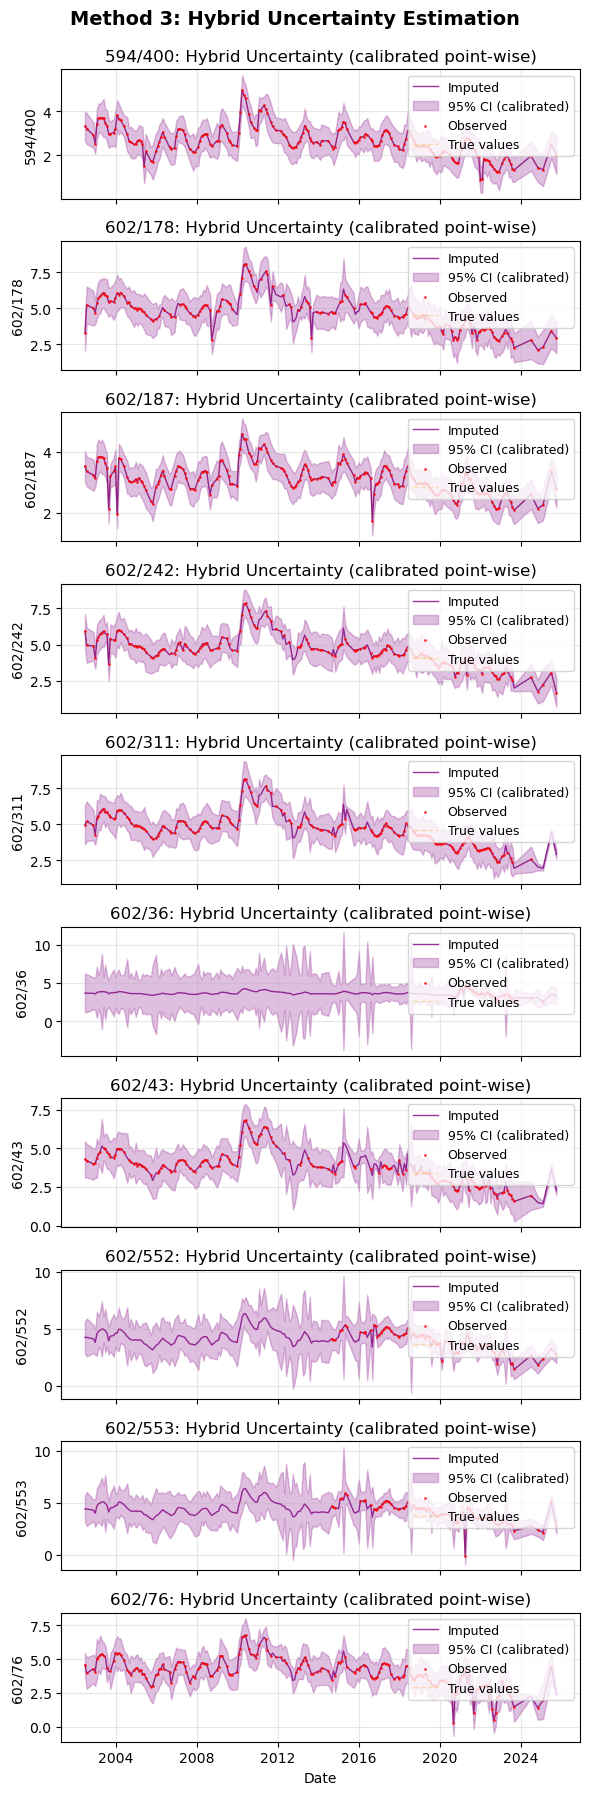

In [13]:
# Visualize Hybrid results
fig, axes = plt.subplots(len(df.columns), 1, figsize=(6, 18), sharex=True)
for i, col in enumerate(df_imputed_hybrid.columns):
    ax = axes[i]
    
    # Plot imputed line
    ax.plot(df_imputed_hybrid.index, df_imputed_hybrid[col], 
           color='purple', linewidth=1, alpha=0.8, label='Imputed', zorder=3)
    
    # Plot uncertainty band (calibrated point-wise)
    ax.fill_between(df_imputed_hybrid.index, 
                   df_lower_hybrid[col], df_upper_hybrid[col],
                   alpha=0.25, color='purple', label='95% CI (calibrated)', zorder=1)
    
    # Plot observed values
    ax.scatter(df.index, df[col], 
              s=1, alpha=0.7, color='red', label='Observed', zorder=4)
    
    # Plot true values
    ax.plot(df.index, df[col], 
           color='orange', linewidth=1, alpha=0.3, linestyle='--', 
           label='True values', zorder=2)
    
    ax.set_ylabel(col)
    ax.set_title(f'{col}: Hybrid Uncertainty (calibrated point-wise)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Method 3: Hybrid Uncertainty Estimation', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

